[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PerformanceEstimation/Tutorial-SIAM-OP26/blob/main/Part%203%20-%20Dual%2C%20proofs%2C%20and%20design/SIAM_MT_Part2.ipynb)

In [1]:
!pip install pepit==0.5.1
!pip install sympy

# SIAM OP26 Minitutorial on performance estimation problems (part 2)

This notebook provides a simple example illustrating how to extract numerical values for the dual variables to analyze gradient descent in the smooth and strongly convex setting and to exploit them to obtain a worst-case performance bound.
The notebook further shows how to leverage those numerical findings to find and verify convergence proofs using SymPy. 

The base problem is that of minimizing an $L$-smooth $\mu$-strongly convex function
$$ \min_{x\in\mathbb{R}^d} f(x).$$

We start by considering a basic gradient descent 
\begin{align*}
x_{1} &= x_0 - \gamma \nabla f(x_0),\\
\end{align*}
and our first target will be to evaluate a worst-case guarantee $\tau:=\tau(\gamma,L,\mu)$ (or rate, ideally as small as possible) on the quantity $\frac{\|x_1-x_\star\|_2}{\|x_0-x_\star\|_2}\leq \tau$.

<a id="toc"></a>
## Table of Contents
- [1. Gradient descent, distance to a solution](#example1)
- [2. Using SymPy for the distance analysis](#example2)
- [3. Gradient descent, function value accuracy](#example3)
- [4. Designing a one-iteration optimal gradient descent](#example4)
- [5. Designing a two-iteration optimal gradient descent (silver stepsizes)](#example5)

In [2]:
# import PEPit and the required function class
from PEPit import PEP
from PEPit.functions import SmoothStronglyConvexFunction

# import numpy and matplotlib
import numpy as np
import matplotlib.pyplot as plt

For simplicity, let us carry out the analysis for specific parameter values.

In [3]:
# set up the smoothness and strong convexity constant (for most of the notebook)
L, mu = 1, .1

##  1. Gradient descent, distance to a solution (numerical) <a class="anchor" id="example1"></a>



### 1.1. Primal PEP (numerical)

We start by a direct attempt: fix class parameters $L,\mu$ (chosen above) and experiment with different step size values $\gamma$. Verify that the obtained convergence rate is indeed smaller than one only when $\gamma\in\left(0,\frac{2}{L}\right)$. Further verify that it matches the well-known $\tau_\star=\max\{(1-\gamma L)^2,(1-\gamma\mu)^2\}$ that corresponds to gradient descent running on either $f(x)=\frac{L}{2}x^2$ or  $f(x)=\frac{\mu}{2}x^2$.


In [4]:
def wc_gradient_descent_distance(mu,L,gamma, verbose):
    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    f = problem.declare_function(SmoothStronglyConvexFunction, L=L, mu=mu)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point()

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition((x0 - xs) ** 2 <= 1)

    # Run 1 step of the gradient method with stepsize gamma
    x1 = x0 - gamma * f.gradient(x0) 

    # Set the performance metric to the function values accuracy
    problem.set_performance_metric( (x1 - xs) ** 2 ) 

    # Solve the PEP
    pepit_verbose = max(verbose, 0)
    pepit_tau = problem.solve(verbose=pepit_verbose)

    # outputs optimal value and list of constraints (with their associated dual variables)
    return pepit_tau, problem._list_of_prepared_constraints 

The following pieces of code compute and plot the numerical worst-case guarantees as a function of the tested step size value $\gamma$, for fixed $\mu,L$.

In [6]:
# use a lambda function to encode our guess about the worst-case rate (given here):
known_worst_case_rate = lambda gamma: max((1 - gamma * L)**2, (1 - gamma * mu)**2) 

Compare your expression to numerical values

In [7]:
verbose = 0

gamma_min, gamma_max = -1, 3
nb_gammas = 50
gamma_list = np.linspace(gamma_min,gamma_max,nb_gammas)

pepit_worst_case_value = list()
known_worst_case_value = list()

for gamma in gamma_list:
    pepit_tau, _ = wc_gradient_descent_distance(mu,L,gamma, verbose)
    pepit_worst_case_value.append(pepit_tau)
    known_worst_case_value.append(known_worst_case_rate(gamma))

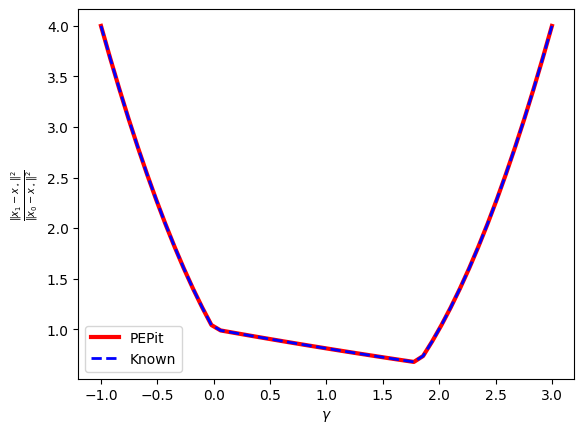

In [8]:
plt.plot(gamma_list, pepit_worst_case_value, color='red', linestyle='-', linewidth=3, label='PEPit')
plt.plot(gamma_list, known_worst_case_value, color='blue', linestyle='--', linewidth=2, label='Known')

plt.legend()
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\frac{\|x_1 - x_\star\|^2}{\|x_0 - x_\star\|^2}$')

plt.show()

One can admit that the match between PEPit's results and the known convergence rate is pretty good.

### 1.2. Dual PEP (numerical)

Let us also extract the dual variables. The next lines examplify how to do this extraction for given values of the parameters, and we integrate it in a loop for plotting below.

In [9]:
verbose = 0
gamma = 1/L

pepit_tau, list_of_constraints = wc_gradient_descent_distance(mu, L, gamma, verbose)

nb_cons = len(list_of_constraints)

for i in range(nb_cons):
    print('Constraint \"{}\" value: {}'.format(list_of_constraints[i].get_name(),
                                               list_of_constraints[i]._dual_variable_value))

Constraint "Performance metric 1" value: 1.0
Constraint "Initial condition" value: 0.8100000006611664
Constraint "IC_Function_0_smoothness_strong_convexity(Point_0, Point_1)" value: 1.800009898700675
Constraint "IC_Function_0_smoothness_strong_convexity(Point_1, Point_0)" value: 1.800009898700675


One can observe that the performance estimation problem is actually involving 4 constraints, 2 of which are of interest for us: the 3rd and 4th ones (that encode the fact the function is smooth and strongly convex). We can therefore extract their values in a loop, plot them, and expect their closed-forms to be nice. Perhaps one could even guess their values.

In [10]:
verbose = 0

gamma_min, gamma_max = -1, 3
nb_gammas = 50
gamma_list = np.linspace(gamma_min,gamma_max,nb_gammas)

pepit_worst_case_value = list()
pepit_dual_value1 = list()
pepit_dual_value2 = list()

for gamma in gamma_list:
    pepit_tau, list_of_constraints = wc_gradient_descent_distance(mu,L,gamma, verbose)
    pepit_worst_case_value.append(pepit_tau)
    pepit_dual_value1.append(list_of_constraints[2]._dual_variable_value)
    pepit_dual_value2.append(list_of_constraints[3]._dual_variable_value)

Use a **lambda** function to make a guess on the values of the multipliers

In [13]:
candidate_lambda = lambda gamma: max(abs(1-gamma*L),abs(1-gamma*mu))*2*abs(gamma)
# Hint:
# 1) try with 0 (and run the next cells to check the lambda values) and observe that they are equal.
# 2) search lambda's in the form C * max(abs(1-gamma*L),abs(1-gamma*mu))*abs(gamma)

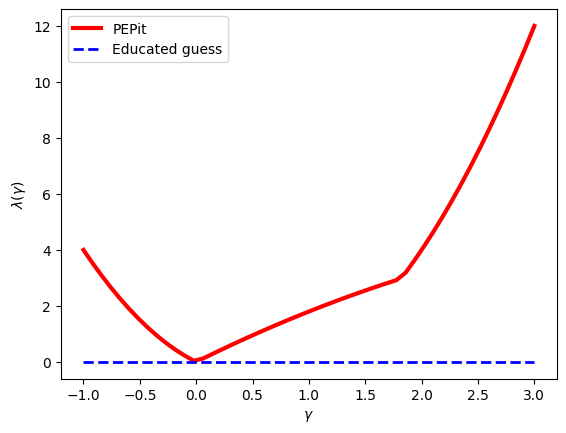

In [14]:
candidate_lambda_list = [ candidate_lambda(gamma) for gamma in gamma_list ]
plt.plot(gamma_list, pepit_dual_value1, color='red', linestyle='-', linewidth=3, label='PEPit')
plt.plot(gamma_list, candidate_lambda_list, color='blue', linestyle='--', linewidth=2, label='Educated guess')

plt.legend()
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\lambda(\gamma)$')

plt.show()

<div align="right"><a href="#toc">↩ Back to TOC</a></div>

## 2. Gradient descent, distance to a solution (symbolics) <a class="anchor" id="example2"></a>

This section requires [Sympy](https://www.sympy.org/en/index.html) (should have been installed in the beginning of the notebook via 
!pip install sympy).

In [ ]:
import sympy as sm

### 2.1. Forming the LMI

Let us recall the target: find the smallest $\tau:=\tau(\gamma,L,\mu)\geq 0$ so that $\|x_1-x_\star\|_2^2\leq \tau^2\|x_0-x_\star\|^2_2$ is valid for all problem in the class, and any initialization $x_0$, with $x_1=x_0-\gamma \nabla f(x_0)$.

First, we introduce symbols for the parameters

In [ ]:
# create symbols for the problem parameters:
L = sm.Symbol('L')
mu = sm.Symbol('mu')
gamma = sm.Symbol('gamma')

Then, we introduce temporary symbols for the 'primal variables':

In [ ]:
# create symbols for the "primal" variables:
x0 = sm.Symbol('x0')
g0 = sm.Symbol('g0')
f0 = sm.Symbol('f0')
xs = 0 # wlog, x_* = 0
gs = 0 # constraint g_* = 0
fs = 0 # wlog, f_* = 0

# define x1 using previous symbols:
x1 = x0 - gamma * g0 

Then, we introduce the constraints and dual variables (do as if $x_0$ and $g_0$ were scalar-valued):

In [ ]:
# the two interpolation constraints in the form "constraint <= 0"
constraint1 = f0 - fs + g0*(xs-x0) + 1/2/L * g0**2 + mu/(2*(1-mu/L)) * (x0-xs-1/L*g0)**2
constraint2 = fs - f0 + 1/2/L * g0**2 + mu/(2*(1-mu/L)) * (x0-xs-1/L*g0)**2
# the objective and the "initial condition" constraint: (also in the form "constraint <= 0")
primal_objective = (x1-xs)**2
initial_condition = (x0-xs)**2-1

# create symbols for the "dual" variables
tau = sm.Symbol('tau')
l1 = sm.Symbol('lambda_1')
l2 = sm.Symbol('lambda_2')

Finally, we write the Lagrangian

In [ ]:
# Lagrangian:
Lagrangian = primal_objective - l1*constraint1 - l2*constraint2 - tau * initial_condition

Since our expressions are quadratic in $(x_0,g_0)$, the LMI is actually given by the Hessian of the Lagrangian wrt $(x_0,g_0)$.
Alternatively, one can compute the matrices $A_i$ and vectors $b_i$ that would encode the constraints as $\mathrm{Tr}(A_i G)+b_i^T F\leq 0$.

In [ ]:
# This is the LMI:
LMI = sm.simplify(sm.hessian( -Lagrangian , (x0,g0))/2)

LMI # this one should be PSD (this is a constraint on the dual side)

Similarly, the linear constraint on the dual is the gradient wrt $f_0$:

In [ ]:
# This is the linear constraint ==0 in the LMI
LinearConst = sm.simplify(sm.diff(-Lagrangian,f0))

LinearConst # show linear constraint (==0)

#### Verify that our candidate multipliers produce dual feasible points

For simplicity, set $\gamma=\tfrac1L$. What are the corresponding values for your candidates $\tau$ and $\lambda_1,\lambda_2$?

In [ ]:
# Specialize the LMI to gamma=1/L
fixed_gamma = 1/L

LMI_fixed_gamma = sm.simplify(LMI.subs(gamma,fixed_gamma)) #substitute gamma for its expression

LMI_fixed_gamma

In [ ]:
# Specialize the LMI to the specific values you have guessed

candidate_expression_lambda = 2 * fixed_gamma * (1 - mu * fixed_gamma)
candidate_expression_tau = (1 - mu * fixed_gamma )**2

# Below we substitute all our candidates
LMI_simplified = sm.simplify(LMI_fixed_gamma.subs(l2,l1))
LMI_simplified = sm.simplify(LMI_simplified.subs(l1,candidate_expression_lambda))
LMI_simplified = sm.simplify(LMI_simplified.subs(tau,candidate_expression_tau))
LMI_simplified

Is this matrix PSD? What do we conclude?

Just to check:

In [ ]:
LMI_simplified.eigenvals()

In this example, we *guessed* the closed-forms. For this simple SDP, it was actually not necessary, but that will be sufficient for our purposes today (see comments below).

### 2.2. An equivalent proof without (explicit) SDPs

Re-introduce all the symbols and scalar values

In [ ]:
# problem parameters
L, mu, gamma = sm.symbols('L mu gamma')

# primal variables
x0, g0, f0 = sm.symbols('x0 g0 f0')
xs, gs, fs = 0, 0, 0  # wlog optimum at zero

# dual variables
tau = (1 - mu * gamma)**2
l1 = 2 * gamma * (1 - mu * gamma)
l2 = l1

# interpolation inequality factory
interp_ij = lambda xi, gi, fi, xj, gj, fj: (
    fi - fj + gi*(xj-xi) + (gi-gj)**2/(2*L)
    + mu/(2*(1-mu/L)) * (xi-xj-(gi-gj)/L)**2
)

# algorithm (GD)
x1 = x0 - gamma * g0

# constraints (≤ 0)
constraint1 = interp_ij(x0, g0, f0, xs, gs, fs)
constraint2 = interp_ij(xs, gs, fs, x0, g0, f0)

# objective and initial condition
performance_measure = (x1 - xs)**2
initial_condition = (x0 - xs)**2 

Now: we need to check equality between the following weighted sum and the reformulation:

In [ ]:
# Weighted sum: this produces
weighted_sum = l1 * constraint1 + l2 * constraint2

# Reformulation
reformulation = performance_measure - tau * initial_condition + gamma * (2 - gamma * (L + mu))/(L - mu) * (mu * (x0 - xs) - g0)**2

Since we are checking equality of expressions that are linear in $f_0$ and quadratic in $(x_0,g_0)$, we can just check that the expressions match in the scalar case $x_0,g_0\in\mathbb{R}$, where both expressions should be equal:

In [ ]:
# Verify equivalence
residual = sm.simplify(weighted_sum - reformulation)
residual

**Bonus.** About solving the parametric linear matrix inequalities without numerical while this is a pain in general (see, e.g., [4] for more precise statements), this one should not cause any problem  (see, e.g., a more complete example [here](https://github.com/PerformanceEstimation/PEPit/blob/master/ressources/demo/PEPit_demo_extracting_a_proof.ipynb)).

<div align="right"><a href="#toc">↩ Back to TOC</a></div>

## 3. Gradient descent, function value accuracy <a class="anchor" id="example3"></a>

Let us continue with the a similar exercise, but now by changing the specific quantity under our radar to function values. Practically speaking, this means changing both the performance metric and the initial condition in the previous code. Executing the code in the same fashion as before, we observe the exact same worst-case ratios, but the LMI already becomes more intricate.

The interested reader can find a more complete version of this notebook [here](https://github.com/PerformanceEstimation/PEPit/blob/master/ressources/demo/PEPit_demo_extracting_a_proof.ipynb).

In [ ]:
# Fix parameters (necessary because we redefined them as symbols)
L, mu = 1, .1

In [ ]:
def wc_gradient_descent_function_values(mu, L, gamma, verbose):
    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    f = problem.declare_function(SmoothStronglyConvexFunction, L=L, mu=mu)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point()

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition( f(x0) - fs <= 1) 

    # Run n steps of the GD method
    x1 = x0 - gamma * f.gradient(x0)

    # Set the performance metric to the function values accuracy
    problem.set_performance_metric( f(x1) - fs )

    # Solve the PEP
    pepit_verbose = max(verbose, 0)
    pepit_tau = problem.solve(verbose=pepit_verbose)

    return pepit_tau, problem._list_of_prepared_constraints # outputs optimal value and list of constraints (with their associated dual variables)

As before, one can compare the known convergence rate for distance to the function value one:

In [ ]:
known_worst_case_rate = lambda gamma: max((1 - gamma * L)**2, (1 - gamma * mu)**2) 

for instance via numerics:

In [ ]:
verbose = 0

gamma_min, gamma_max = -1, 3
nb_gammas = 50
gamma_list = np.linspace(gamma_min,gamma_max,nb_gammas)

pepit_worst_case_value = list()
known_worst_case_value = list()

for gamma in gamma_list:
    pepit_tau, _ = wc_gradient_descent_function_values(mu, L, gamma, verbose)
    pepit_worst_case_value.append(pepit_tau)
    known_worst_case_value.append(known_worst_case_rate(gamma))

plt.plot(gamma_list, pepit_worst_case_value, color='red', linestyle='-', linewidth=3, label='PEPit')

plt.plot(gamma_list, known_worst_case_value, color='blue', linestyle='--', linewidth=2, label='Known')

plt.legend()
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\frac{f(x_1) - f_\star}{f(x_0) - f_\star}$')

plt.show()

However, a bad surprise appears when inspecting the problem: there are actually more constraints, and hence possibly more dual multipliers to be identified. While the reason for this is relatively clear (primal has more constraint), there are a few negative consequences of this fact. First, let us investigate a bit the values of those (additional) dual variables.

In [ ]:
verbose = 0
gamma = 1/L

pepit_tau, list_of_constraints = wc_gradient_descent_function_values(mu,L,gamma, verbose)

nb_cons = len(list_of_constraints)

for i in range(nb_cons):
    print('Constraint \"{}\" value: {}'.format(list_of_constraints[i].get_name(),
                                               list_of_constraints[i]._dual_variable_value))

To get a clearer view, let us plot all these values as a function of $\gamma$ again. The code below is intentionally a bit raw for readability purposes---there are six dual variables to explore.

In [ ]:
verbose = 0

gamma_min, gamma_max = -1, 3
nb_gammas = 50
gamma_list = np.linspace(gamma_min,gamma_max,nb_gammas)

pepit_worst_case_value = list()
pepit_dual_value1 = list()
pepit_dual_value2 = list()
pepit_dual_value3 = list()
pepit_dual_value4 = list()
pepit_dual_value5 = list()
pepit_dual_value6 = list()
known_worst_case_value = list()

for gamma in gamma_list:
    pepit_tau, list_of_constraints = wc_gradient_descent_function_values(mu,L,gamma, verbose)
    pepit_worst_case_value.append(pepit_tau)
    known_worst_case_value.append(max((1-gamma*L)**2,(1-gamma*mu)**2))
    pepit_dual_value1.append(list_of_constraints[2]._dual_variable_value)
    pepit_dual_value2.append(list_of_constraints[3]._dual_variable_value)
    pepit_dual_value3.append(list_of_constraints[4]._dual_variable_value)
    pepit_dual_value4.append(list_of_constraints[5]._dual_variable_value)
    pepit_dual_value5.append(list_of_constraints[6]._dual_variable_value)
    pepit_dual_value6.append(list_of_constraints[7]._dual_variable_value)


plt.plot(gamma_list, pepit_dual_value1, color='red', linestyle='-', linewidth=3, label=r'$\lambda_1$')
plt.plot(gamma_list, pepit_dual_value2, color='blue', linestyle='-', linewidth=3, label=r'$\lambda_2$')
plt.plot(gamma_list, pepit_dual_value3, color='green', linestyle='-', linewidth=3, label=r'$\lambda_3$')
plt.plot(gamma_list, pepit_dual_value4, color='gold', linestyle='-', linewidth=3, label=r'$\lambda_4$')
plt.plot(gamma_list, pepit_dual_value5, color='orange', linestyle='-', linewidth=3, label=r'$\lambda_5$')
plt.plot(gamma_list, pepit_dual_value6, color='brown', linestyle='-', linewidth=3, label=r'$\lambda_6$')

plt.legend()
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\lambda_i(\gamma)$')

plt.show()

Given the apparent ugliness of those dual variables (guessing closed-forms appears like a much more challenging game!), one could directly try to sparsify the proof (even if there was a sparser proof, an interior-point solver.would typically not find it). The following implementation encodes the fact that we force certain multipliers to be zero (more details on the greedy procedure are provided in [here, Section 3](https://github.com/PerformanceEstimation/PEPit/blob/master/ressources/demo/PEPit_demo_extracting_a_proof.ipynb)).

In [ ]:
def wc_gradient_descent_function_values_sparse_proof(mu,L,gamma, verbose):
    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    f = problem.declare_function(SmoothStronglyConvexFunction, L=L, mu=mu)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point()

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition( f(x0) - fs <= 1)

    # Run n steps of the GD method
    x1 = x0 - gamma * f.gradient(x0)

    # Set the performance metric to the function values accuracy
    problem.set_performance_metric( f(x1) - fs )

    # Output prepared problem
    pepit_verbose = max(verbose, 0)
    problem._prepare_constraints(verbose=pepit_verbose)
    
    # Complete below: what constraints should be deactivated?
    problem._list_of_prepared_constraints[4].deactivate()
    problem._list_of_prepared_constraints[6].deactivate()
    problem._list_of_prepared_constraints[7].deactivate()

    pepit_tau = problem.solve(verbose=pepit_verbose)

    return pepit_tau, problem._list_of_prepared_constraints

Since we are now dealing with a relaxation, we must verify that the rates that we can certify match those that we could certify without the relaxation.

In [ ]:
verbose = 0

gamma_min, gamma_max = 0.001, 2 # only test the step sizes of interest here
nb_gammas = 50
gamma_list = np.linspace(gamma_min,gamma_max,nb_gammas)

pepit_worst_case_value = list()
known_worst_case_value = list()

for gamma in gamma_list:
    pepit_tau, _ = wc_gradient_descent_function_values_sparse_proof(mu,L,gamma, verbose)
    pepit_worst_case_value.append(pepit_tau)
    known_worst_case_value.append(known_worst_case_value_function(gamma))

plt.plot(gamma_list, pepit_worst_case_value, color='red', linestyle='-', linewidth=3, label='PEPit')

plt.plot(gamma_list, known_worst_case_value, color='blue', linestyle='--', linewidth=2, label='Known')

plt.legend()
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\frac{f(x_1) - f_\star}{f(x_0) - f_\star}$')

plt.show()

Since the values are matching, we proceed and check the values of the remaining nonzero dual variables.

In [ ]:
verbose = 0

gamma_min, gamma_max = 0.001, 2
nb_gammas = 50
gamma_list = np.linspace(gamma_min,gamma_max,nb_gammas)

pepit_worst_case_value = list()
pepit_dual_value1 = list()
pepit_dual_value2 = list()
pepit_dual_value3 = list()
pepit_dual_value4 = list()
pepit_dual_value5 = list()
pepit_dual_value6 = list()
known_worst_case_value = list()

for gamma in gamma_list:
    pepit_tau, list_of_constraints = wc_gradient_descent_function_values_sparse_proof(mu,L,gamma, verbose)
    pepit_worst_case_value.append(pepit_tau)
    known_worst_case_value.append(max((1-gamma*L)**2,(1-gamma*mu)**2))
    pepit_dual_value1.append(list_of_constraints[2]._dual_variable_value)
    pepit_dual_value2.append(list_of_constraints[3]._dual_variable_value)
    pepit_dual_value3.append(list_of_constraints[4]._dual_variable_value)
    pepit_dual_value4.append(list_of_constraints[5]._dual_variable_value)
    pepit_dual_value5.append(list_of_constraints[6]._dual_variable_value)
    pepit_dual_value6.append(list_of_constraints[7]._dual_variable_value)


plt.plot(gamma_list, pepit_dual_value1, color='red', linestyle='-', linewidth=3, label=r'$\lambda_1$')
plt.plot(gamma_list, pepit_dual_value2, color='blue', linestyle='-', linewidth=3, label=r'$\lambda_2$')
plt.plot(gamma_list, pepit_dual_value3, color='green', linestyle='-', linewidth=3, label=r'$\lambda_3$')
plt.plot(gamma_list, pepit_dual_value4, color='gold', linestyle='-', linewidth=3, label=r'$\lambda_4$')
plt.plot(gamma_list, pepit_dual_value5, color='orange', linestyle='--', linewidth=3, label=r'$\lambda_5$')
plt.plot(gamma_list, pepit_dual_value6, color='brown', linestyle='-.', linewidth=3, label=r'$\lambda_6$')

plt.legend()
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\lambda_i(\gamma)$')

plt.show()

... and it looks much better. One can now play the same game as for the distance problem! 

As a hint, the LMI can now be obtained as follows

In [ ]:
import sympy as sm

# create symbols for the problem parameters:
L = sm.Symbol('L')
mu = sm.Symbol('mu')
gamma = 1/L

# create symbols for the "primal" variables:
x0 = sm.Symbol('x0')
g0 = sm.Symbol('g0')
g1 = sm.Symbol('g1')
f0 = sm.Symbol('f0')
f1 = sm.Symbol('f1')
xs = 0 # wlog, x_* = 0
gs = 0 # constraint g_* = 0
fs = 0 # wlog, f_* = 0
x1 = x0 - gamma * g0 # define x1 using previous symbols:

# create symbols for the "dual" variables
tau = sm.Symbol('tau')
l1 = sm.Symbol('lambda_1')
l2 = sm.Symbol('lambda_2')
l4 = sm.Symbol('lambda_4')


# the two interpolation constraints in the form "constraint <= 0"
constraint1 = f0 - fs + g0*(xs-x0) + 1/2/L * g0**2 + mu/(2*(1-mu/L)) * (x0-xs-1/L*g0)**2
constraint2 = f1 - fs + g1*(xs-x1) + 1/2/L * g1**2 + mu/(2*(1-mu/L)) * (x1-xs-1/L*g1)**2
constraint4 = f1 - f0 + g1*(x0-x1) + 1/2/L * (g0-g1)**2 + mu/(2*(1-mu/L)) * (x1-x0-1/L*g1+1/L*g0)**2

# the objective and the "initial condition" constraint: (also in the form "constraint <= 0")
primal_objective = f1 - fs
initial_condition = f0 - fs

# Lagrangian:
Lagrangian = - l1*constraint1 - l2*constraint2 - l4*constraint4 - tau * initial_condition + primal_objective

# This is the LMI:
LMI = sm.simplify(sm.hessian( -Lagrangian , (x0,g0,g1))/2) 
LMI


In [ ]:
LinearConst1 = sm.simplify(sm.diff(-Lagrangian,(f0)))
LinearConst2 = sm.simplify(sm.diff(-Lagrangian,(f1)))

[LinearConst1, LinearConst2] # show linear constraint (==0)

<div align="right"><a href="#toc">↩ Back to TOC</a></div>

## 4. Designing an optimal gradient descent (one iteration) <a class="anchor" id="example4"></a>

Let us now consider the same optimization setup: we want to minimize a smooth strongly convex function
$$ \min_{x\in\mathbb{R}^d} f(x),$$
using a gradient algorithm. That is, we will iterate:
\begin{align*}
x_{1} &= x_0 - \gamma \nabla f(x_0),\\
\end{align*}
and our goal will be to design the stepsize $\gamma$. We proceed with the following choice:

$$\min_{\gamma}\,\, \max_{f\in\mathcal{F}_{\mu,L}} \left\{ \frac{\|x_1-x_\star\|^2_2}{\|x_0-x_\star\|^2_2} \, : \, x_2 \text{ obtained from } x_{1} = x_0 - \gamma \nabla f(x_0) \right\}.$$

assuming we don't already know the answer. 

Start with a few imports used throughout this section.

In [ ]:
# import PEPit and the required function class
from PEPit import PEP
from PEPit.functions import SmoothStronglyConvexFunction

# import numpy and matplotlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from math import sqrt

For simplicity, let us again carry out the analysis for specific parameter values.


In [ ]:
L, mu = 1, .1

### 4.1. Back to base gradient descent: numerical experiments

We first consider a direct approach: fix the class parameters $L, \mu$ (chosen below) and experiment with different step sizes $\gamma$. 

The following code is standard and was already introduced in the previous exercise sessions.

In [ ]:
def wc_gradient_descent(L, mu, gammas, verbose = 0):
    
    n = len(gammas)
    
    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    func = problem.declare_function(SmoothStronglyConvexFunction, L=L, mu=mu)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = func.stationary_point(name='xs')

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point(name='x0')

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition((x0 - xs) ** 2 <= 1)

    # Run n steps of the GD method
    x = x0
    for i in range(n):
        x = x - gammas[i] * func.gradient(x)
        x.set_name('x{}'.format(i+1))

    # Set the performance metric to the function values accuracy
    problem.set_performance_metric( (x - xs) ** 2 )

    # Solve the PEP
    pepit_verbose = max(verbose, 0)
    pepit_tau = problem.solve(verbose=pepit_verbose)
    list_of_constraints = problem._list_of_prepared_constraints


    # Return the worst-case guarantee of the evaluated method together with the computed dual values and dual slack matrix S ("residual"):
    return pepit_tau, list_of_constraints, func.get_class_constraints_duals(), problem.residual

We now verify the rate for $(\mu, L) = (0.1, 1)$ over a grid of step sizes.

In [ ]:
L = 1.
mu = .1
gamma_min, gamma_max = -.5, 2.5
nb_gammas = 400
gamma_list = np.linspace(gamma_min,gamma_max,nb_gammas)

pepit_worst_case_value = list()

for i, gamma in enumerate(gamma_list):
    pepit_tau, _, _, _ = wc_gradient_descent(mu=mu,L=L,gammas=[gamma])
    pepit_worst_case_value.append(pepit_tau)
    print(f'{i + 1} / {nb_gammas} grid points computed', end='\r', flush=True)
    
plt.plot(gamma_list, pepit_worst_case_value, color='red', linestyle='-', linewidth=3, label='PEPit')

plt.legend()
plt.xlabel(r'Stepsize $\gamma$')
plt.ylabel(r'Worst-case $\frac{\|x_1-x_\star\|^2}{\|x_0-x_\star\|^2}$')

plt.show()

*Refresher from above.* Identify the pattern in the inequalities: does it make sense, and can you explain it in light of the PEP theory you know?
How many *interpolation constraints* are active?

In [ ]:
tested_stepsize = 1/L
pepit_tau, list_of_constraints, tab, res  = wc_gradient_descent(1, .1, [tested_stepsize])

print(tab["smoothness_strong_convexity"])

Now, our goal is to compute the optimal point by observing a few properties of the corresponding PEP objects, assuming we do not already know that its parametric value is $2/(L+\mu)$. In particular, observe the value of the residual matrix (at the best point of the grid) and compare it with its value for other step sizes. Can you explain this intuitively? Does it give you a hint on how to algebraically characterize this optimal step size?

In [ ]:
# index of the best stepsize using np.argmin():
idx_best = np.argmin(pepit_worst_case_value) 
gamma_best = gamma_list[idx_best]
tau_best = pepit_worst_case_value[idx_best]

pepit_tau, list_of_constraints, tab, res  = wc_gradient_descent(L=L, mu=mu, gammas=[gamma_best])

print(res) # This is the "S" matrix from the slides

Now that you witnessed/observe this (likely) algebraic property of the optimal step size, let us try to compute it directly via symbolic computations (using SymPy).

### 4.2. Rediscovering optimal parameters for gradient descent 

In [ ]:
# Proof with SymPy :)
import sympy as sm


# We start by writing the SDP in dual form:

# problem parameters
L, mu, gamma = sm.symbols('L mu gamma')
# primal variables
x0, g0, f0 = sm.symbols('x0 g0 f0')
xs, gs, fs = 0, 0, 0  # wlog optimum at zero
# dual variables
tau, l1, l2 = sm.symbols('tau lambda_1 lambda_2')
# interpolation inequality factory
interp_ij = lambda xi, gi, fi, xj, gj, fj: (
    fi - fj + gi*(xj-xi) + (gi-gj)**2/(2*L)
    + mu/(2*(1-mu/L)) * (xi-xj-(gi-gj)/L)**2
)
# algorithm (GD)
x1 = x0 - gamma * g0 

# constraints (≤ 0)
constraint1 = interp_ij(x0, g0, f0, xs, gs, fs)
constraint2 = interp_ij(xs, gs, fs, x0, g0, f0)

# objective and initial condition
primal_objective = (x1 - xs)**2
initial_condition = (x0 - xs)**2

# Lagrangian
Lagrangian = (
    - l1 * constraint1
    - l2 * constraint2
    - tau * initial_condition
    + primal_objective
)

# Linear matrix inequality (aka. residual on the dual side):
LMI = sm.simplify(sm.hessian(-Lagrangian, (x0, g0)) / 2)
# Linear constraint
Linear = sm.diff(-Lagrangian, f0)

We can now proceed step by step to cancel both terms, namely the LMI/residual and the linear constraint. We show below how to do everything at once, but the step-by-step approach is pedagogically useful and might help one to get used to SymPy:

In [ ]:
LMI

In [ ]:
Linear

In [ ]:
# first: substitute one dual variable by the other (as the linear constraint forces them to be equal)
LMI = LMI.subs(l2,l1)
LMI

In [ ]:
# Then: pick tau so as to cancel out first entry of the LMI:
tau_val = sm.solve(LMI[0,0],tau)
LMI = sm.simplify(LMI.subs(tau,tau_val[0]))
LMI

In [ ]:
# Then: pick \lambda_1 to cancel out the off-diagonal entry:
l1_val = sm.solve(LMI[1,0],l1)
LMI = sm.simplify(LMI.subs(l1,l1_val[0]))
LMI

In [ ]:
# Then: pick gamma to cancel out the last (2,2) diagonal entry:
gamma_val = sm.solve(LMI[1,1],gamma) 

# The optimal step size is thus one among the solutions:
print('There are {} possible solutions'.format(len(gamma_val)))
for i in range(len(gamma_val)):
    print('\t Solution {}: gamma={},'.format(i, gamma_val[i]))

Nice: this is very much in line with what one would expect.
The next lines perform exactly the same operations, but all at once.

In [ ]:
# problem parameters
L, mu, gamma = sm.symbols('L mu gamma')
# primal variables
x0, g0, f0 = sm.symbols('x0 g0 f0')
xs, gs, fs = 0, 0, 0  # wlog optimum at zero
# dual variables
tau, l1, l2 = sm.symbols('tau lambda_1 lambda_2')
# interpolation inequality factory
interp_ij = lambda xi, gi, fi, xj, gj, fj: (
    fi - fj + gi*(xj-xi) + (gi-gj)**2/(2*L)
    + mu/(2*(1-mu/L)) * (xi-xj-(gi-gj)/L)**2
)
# algorithm (GD)
x1 = x0 - gamma * g0 

# constraints (≤ 0)
constraint1 = interp_ij(x0, g0, f0, xs, gs, fs)
constraint2 = interp_ij(xs, gs, fs, x0, g0, f0)

# objective and initial condition
primal_objective = (x1 - xs)**2
initial_condition = (x0 - xs)**2 

# Lagrangian
Lagrangian = (
    - l1 * constraint1
    - l2 * constraint2
    - tau * initial_condition
    + primal_objective
)

# LMI
LMI = sm.simplify(sm.hessian(-Lagrangian, (x0, g0)) / 2)
Linear = sm.simplify(sm.diff(-Lagrangian,f0))
#LMI = LMI.subs(l2,l1)

sols = sm.solve([LMI,Linear],tau,l1,l2,gamma)

What do the different solutions correspond to?

In [ ]:
print('There are {} possible solutions'.format(len(sols)))
for i in range(len(gamma_val)):
    print('\t Solution {}:'.format(i))
    print('\t\t tau={},'.format(sols[i][0]))
    print('\t\t l1={},'.format(sols[i][1]))
    print('\t\t l2={},'.format(sols[i][2]))
    print('\t\t gamma={},'.format(sols[i][3]))

A natural next question is how to turn these findings into a proof of the result:

Method: $x_1=x_0-\gamma \nabla f(x_0)$. The optimal step size is $\tfrac{2}{L+\mu}$, and the proof is the one you already did above! Consider the weighted sum of

- interpolation between $x_0$ and $x_\star$ with weight $\lambda_1=2\gamma (1-\gamma\mu)$
- interpolation between $x_\star$ and $x_0$ with weight $\lambda_2=\lambda_1$

The weighted sum gives (e.g., by completing the squares; a.k.a., "analytical Cholesky"):
$$\|x_1-x_\star\|^2\leq (1-\gamma \mu)^2 \|x_0-x_\star\|^2 - \tfrac{\gamma(2-\gamma(L+\mu))}{L-\mu}\|\mu (x_0-x_\star)-\nabla f(x_0)\|^2.$$

What we did here: corresponds to cancelling the last term to obtain the value for $\gamma$, and the rate $\left(\frac{L-\mu}{L+\mu}\right)^2$.

**Note:** this kind of *magic* (optimal method has zero slack matrix) is not universal. However, it is observed that optimal methods typically have such low-rank structures (not necessarily zero) that make them potentially "easier" to identify.

<div align="right"><a href="#toc">↩ Back to TOC</a></div>

## 5. Two-step gradient descent --- a.k.a., the Silver step-size schedule [5] in its simplest case ($n=2$) <a class="anchor" id="example5"></a>

Let us now consider the same optimization setup: we want to minimize a smooth strongly convex function
$$ \min_{x\in\mathbb{R}^d} f(x),$$
but using a multistep gradient algorithm. That is, we will iterate:
\begin{align*}
x_{1} &= x_0 - \gamma_1 \nabla f(x_0),\\
x_{2} &= x_1 - \gamma_2 \nabla f(x_1),
\end{align*}
and our goal will be to design the pair $(\gamma_1, \gamma_2)$. We proceed with the following choice:

$$\min_{\gamma_1,\gamma_2}\,\, \max_{f\in\mathcal{F}_{\mu,L}} \left\{ \frac{\|x_2-x_\star\|^2_2}{\|x_0-x_\star\|^2_2} \, : \, x_2 \text{ obtained from } x_{1} = x_0 - \gamma_1 \nabla f(x_0),\,x_{2} = x_1 - \gamma_2 \nabla f(x_1)  \right\}.$$


To do this, we will follow steps similar to those used for vanilla GD:
- observe the numerics,
- try to exploit an observation made on the numerics (e.g., slack matrix has a simple structure).

For simplicity, let us again carry out the analysis for specific parameter values.

In [ ]:
L, mu = 1, .1

### 5.1. Numerical exploration

The following routine implements grid search for the stepsizes.

In [ ]:
def pepit_grid_search(gamma1_grid, gamma2_grid, mu, L):
    """
    Evaluate wc_gradient_descent on a grid of (gamma1, gamma2).

    Parameters
    ----------
    gamma1_grid : array-like
        Grid values for gamma1.
    gamma2_grid : array-like
        Grid values for gamma2.
    mu, L : float
        Problem parameters.

    Returns
    -------
    G1, G2 : ndarray
        Meshgrid of gamma1 and gamma2.
    tau_grid : ndarray
        Grid of pepit_tau values.
    """

    G1, G2 = np.meshgrid(gamma1_grid, gamma2_grid)
    tau_grid = np.zeros_like(G1)

    total = tau_grid.size

    for k, (i, j) in enumerate(np.ndindex(G1.shape), start=1):
        gamma1 = G1[i, j]
        gamma2 = G2[i, j]

        pepit_tau, _, _, _ = wc_gradient_descent(mu=mu, L=L, gammas=[gamma1, gamma2])
        tau_grid[i, j] = pepit_tau

        print(f'{k} / {total} grid points computed', end='\r', flush=True)

    return G1, G2, tau_grid

def plot_pepit_landscape(G1, G2, tau_grid):
    """
    Plot the contour landscape of pepit_tau and highlight the minimum.

    Parameters
    ----------
    G1, G2 : ndarray
        Meshgrid of gamma1 and gamma2.
    tau_grid : ndarray
        Grid of pepit_tau values.

    Returns
    -------
    i_best, j_best : int
        Indices of the best grid point.
    gamma1_best, gamma2_best : float
        Best step sizes.
    tau_best : float
        Best value of pepit_tau.
    """

    plt.figure()

    levels = np.logspace(
        np.log10(np.nanmin(tau_grid)),
        np.log10(np.nanmax(tau_grid)),
        50
    )

    cf = plt.contourf(
        G1, G2, tau_grid,
        levels=levels,
        cmap='viridis_r',
        norm=LogNorm()
    )

    plt.colorbar(cf)

    # locate minimum
    idx = np.nanargmin(tau_grid)
    i_best, j_best = np.unravel_index(idx, tau_grid.shape)

    gamma1_best = G1[i_best, j_best]
    gamma2_best = G2[i_best, j_best]
    tau_best = tau_grid[i_best, j_best]

    # mark minimum
    plt.scatter(gamma1_best, gamma2_best, s=120, color='red',
                edgecolor='black', zorder=3)

    plt.xlabel(r'$\gamma_1$')
    plt.ylabel(r'$\gamma_2$')
    plt.title(r'Worst-case $\frac{\|x_2-x_\star\|^2}{\|x_0-x_\star\|^2}$')

    plt.show()

    print(f"Best grid index: (i,j) = ({i_best}, {j_best})")
    print(f"gamma1 = {gamma1_best:.4f}, gamma2 = {gamma2_best:.4f}")
    print(f"tau = {tau_best:.4e}")

    return i_best, j_best, gamma1_best, gamma2_best, tau_best

Using the previous pieces of code, perform a grid search over the step sizes and plot the corresponding convergence rate values.
Don't be too greedy (the grid search cost quickly becomes too high) and try to get to a reasonable approximation of the optimal pair $(\gamma_1,\gamma_2)$.


In [ ]:
# plot (2-step): parameterize the grid for the 2D grid search (
# grid parameters:
gamma_min, gamma_max = 0.1, 3.2 
nb_gammas = 30 # do not make this too large :)

# grid search:
gamma1_vals = np.linspace(gamma_min, gamma_max, nb_gammas)
gamma2_vals = gamma1_vals
G1, G2, tau_grid = pepit_grid_search(gamma1_vals, gamma2_vals, mu=mu, L=L)

In [ ]:
_, _, gamma1_best, gamma2_best, tau_best = plot_pepit_landscape(G1, G2, tau_grid)

As we want to find properties of the optimal point, let us refine the grid around the target point (possibly several times)!

In [ ]:
gamma1_min, gamma1_max = 1.383, 1.384 
gamma2_min, gamma2_max = 2.650, 2.651 
nb_gammas = 10

gamma1_vals = np.linspace(gamma1_min, gamma1_max, nb_gammas)
gamma2_vals = np.linspace(gamma2_min, gamma2_max, nb_gammas)

G1, G2, tau_grid = pepit_grid_search(gamma1_vals, gamma2_vals, mu=mu, L=L)
_, _, gamma1_best, gamma2_best, tau_best = plot_pepit_landscape(G1, G2, tau_grid)

What algebraic property do you empirically observe at (or around) this optimal point?
(again: don't hesitate to check the dual slack matrix $S$)

In [ ]:
pepit_tau, list_of_constraints, tab, res  = wc_gradient_descent(L=L, mu=mu, gammas=[gamma1_best, gamma2_best])

print(res) # This is S

In order to help SymPy, we also have to identify the sparsity pattern for the dual variables (and remove potentially useless ones). What do you observe and how would you choose it?

In [ ]:
print(tab["smoothness_strong_convexity"])

### 5.2. Exploiting numerical observations to design the algorithm.

Use SymPy to try to compute the optimal step sizes. 

Recap':
- Method: $x_1=x_0-\gamma_1 \nabla f(x_0)$, $x_2=x_1-\gamma_2 \nabla f(x_1)$.
Let us denote by $\lambda_{i,j}$ the weight for using inequality
$$
0\geq f(x_j) -f(x_i) +\langle \nabla f(x_j);x_i-x_j\rangle + \tfrac{1}{2L}\|\nabla f(x_i)-\nabla f(x_j)\|^2+\tfrac{\mu}{2(1-\mu/L)} \|x_i-x_j-\tfrac1L (\nabla f(x_i)-\nabla f(x_j))\|^2.
$$

- Dual variables: ot seems that we must use the following nonzero values for these weights $\lambda_{i,j}$:
$$
\begin{array}{c|ccc}
(i,j) & \star & 0 & 1 \\
\hline
\star & 0 & ✔ & ✔ \\
0 & 0 & 0 & ✔ \\
1 & ✔ & ✔ & 0
\end{array}
$$

In [ ]:
# problem parameters
L, mu, gamma1, gamma2 = sm.symbols('L mu gamma1 gamma2', positive=True)

# primal variables
x0, g0, g1, f0, f1 = sm.symbols('x0 g0 g1 f0 f1')
xs, gs, fs = 0, 0, 0  # wlog optimum at zero𝑖

x1 = x0 - gamma1 * g0 
x2 = x1 - gamma2 * g1 

# dual variables
tau, ls0, ls1, l01, l1s, l10 = sm.symbols('\tau \lambda_{*0} \lambda_{*1} \lambda_{01} \lambda_{1*} \lambda_{10}')


# interpolation inequality factory
interp_ij = lambda xi, gi, fi, xj, gj, fj: (
    fj - fi + gj*(xi-xj) + (gi-gj)**2/(2*L)
    + mu/(2*(1-mu/L)) * (xi-xj-(gi-gj)/L)**2
)

# constraints (≤ 0)
constraints0 = interp_ij(xs, gs, fs, x0, g0, f0)
constraints1 = interp_ij(xs, gs, fs, x1, g1, f1)
constraint01 = interp_ij(x0, g0, f0, x1, g1, f1)
constraint1s = interp_ij(x1, g1, f1, xs, gs, fs)
constraint10 = interp_ij(x1, g1, f1, x0, g0, f0)

# objective and initial condition
primal_objective = (x2 - xs)**2
initial_condition = (x0 - xs)**2 

# Lagrangian
Lagrangian = (
    - ls0 * constraints0
    - ls1 * constraints1
    - l01 * constraint01
    - l1s * constraint1s
    - l10 * constraint10
    - tau * initial_condition
    + primal_objective
)

# LMI
LMI = sm.simplify(sm.hessian(-Lagrangian, (x0, g0, g1)) / 2)
vars_vec = sm.Matrix([f0, f1])
Linear = sm.Matrix([-Lagrangian]).jacobian(vars_vec)

Using the (guessed) algebraic characterization, let us try to obtain closed-form expressions for all the parameters and dual variables. (This will take a few minutes to run.)

In [ ]:
# find the value of all dual variables (along with the stepsizes) by zeroing-out the linear and LMI constraints
sols = sm.solve([LMI, Linear], tau, ls0, ls1, l01, l1s, l10, gamma1, gamma2)

How many solutions did SymPy find? Can you use the numerical experiments to identify which one is relevant here? **Bonus**: what do the other solutions correspond to?

In [ ]:
print('There are {} solutions'.format(len(sols)))

index_sol = 3
sols_num = [expr.subs(mu, 0.1).subs(L,1).evalf() for expr in sols[index_sol]]
print('Solution {} has convergence rate {} for the specific (L,mu) values above'.format(ind_sol, sols_num[0]))

In [ ]:
sols_num

What are the corresponding expressions for the step sizes?

In [ ]:
simplify_attempt = [sm.simplify(expr) for expr in sols[index_sol]]

print('First step size is {}'.format(simplify_attempt[-2]))
print('Second step size is {}'.format(simplify_attempt[-1]))

In [ ]:
simplify_attempt[-2]

How would you summarize your findings? Do you observe an improvement compared with the classical optimal convergence rate of gradient descent?

#### Summary on Silver steps ($n=2$)


The optimal step sizes are as follows:
\begin{align*}
    \gamma_1 & = \frac{1}{L}\left(\frac{\sqrt{1 + (1-\kappa)^2} - \kappa}{1-\kappa}\right)\\
    \gamma_2 & = \frac{1}{L}\left(\frac{\sqrt{1 + (1-\kappa)^2}+2+\kappa}{1+3\kappa}\right),
\end{align*}
with $\kappa=\tfrac{\mu}{L}$.

The proof consists of performing a weighted sum of inequalities:

- interpolation inequality with $i\leftarrow\star $ and $j\leftarrow0$ and multiplier $\lambda_{\star,0}=\tfrac{2 \gamma_1 (\kappa -1) ((2 \gamma_2-1) \kappa -1)}{\kappa  (\gamma_1 (-\kappa )+\gamma_1+1)+1}$

- interpolation inequality with $i\leftarrow \star $ and $j\leftarrow 1$ and multiplier $\lambda_{\star,1}=\tfrac{2 (\kappa -1) (\gamma_1 (\gamma_2-1) \kappa +\gamma_2)}{\kappa  (\gamma_1 (\kappa -1)-1)-1}$

- interpolation inequality with $i\leftarrow 0$ and $j\leftarrow1$ and multiplier $\lambda_{0,1}=\tfrac{2 \gamma_1 (\kappa -1) (\gamma_1 \kappa -1) ((2 \gamma_2-1) \kappa -1)}{(\gamma_1 \kappa +\gamma_1-2) (\kappa  (\gamma_1 (-\kappa )+\gamma_1+1)+1)}$

- interpolation inequality with $i\leftarrow 1$ and $j\leftarrow\star$ and multiplier $\lambda_{1,\star}=\tfrac{2 (\kappa -1) (\gamma_1 (\gamma_2 \kappa -1)-\gamma_2)}{\kappa  (\gamma_1 (-\kappa )+\gamma_1+1)+1}$

- interpolation inequality with $i\leftarrow 1$ and $j\leftarrow0$ and multiplier $\lambda_{1,0}=\tfrac{2 (\gamma_1-1) \gamma_1 (\kappa -1) ((2 \gamma_2-1) \kappa -1)}{(\gamma_1 \kappa +\gamma_1-2) (\kappa  (\gamma_1 (\kappa -1)-1)-1)}$

Summing all these inequalities can be reformulated as

\begin{equation*}
\begin{aligned}
\|x_2-x_\star\|^2\leq& \left(\tfrac{2 \kappa  (\gamma_1 (-\gamma_2) \kappa +\gamma_1+\gamma_2)}{\kappa  (\gamma_1 (\kappa -1)-1)-1}+1\right)\|x_0-x_\star\|^2\\&-\tfrac{2 \gamma_1 \left(\gamma_1^2 (\kappa -1)-2 \gamma_1 \kappa +2\right) (\gamma_1 \kappa -1) ((2 \gamma_2-1) \kappa -1)}{(\gamma_1 \kappa +\gamma_1-2) (\kappa  (\gamma_1 (\kappa -1)-1)-1)}\|\nabla f(x_0)\|^2\\&-\tfrac{-2 \gamma_1^2 \gamma_2 (\kappa -1) \kappa  (\gamma_2 \kappa +\gamma_2-2)+2 \gamma_1 \left(\gamma_2 \left(3 \gamma_2 \kappa ^2+\gamma_2-2 (\kappa +1)\right)-2 \kappa +2\right)-4 \gamma_2 (\gamma_2 \kappa +\gamma_2-2)}{(\gamma_1 \kappa +\gamma_1-2) (\kappa  (\gamma_1 (\kappa -1)-1)-1)}\|\nabla f(x_1)\|^2.
\end{aligned}
\end{equation*}

Evaluating this expression at the previously chosen values of $\gamma_1$ and $\gamma_2$, we find that the two residual terms are equal to $0$.



#### **Bonus 1:** more iterations? (hint: using Schur complements might help the numerical exploration, and using other computer-algebra software allows going a bit further than with SymPy)


### Try this pattern on a simple quadratic problem and compare it to vanilla gradient descent

In [ ]:
L, mu = 1., 0.1
kappa = mu / L
H = np.array([L, mu])
grad = lambda x: H * x
f = lambda x: 0.5 * (H * x**2).sum()

def run_gd(x0, T):
    x, traj = x0.copy(), [x0.copy()]
    gamma = 2 / (L + mu)
    for _ in range(T):
        x -= gamma * grad(x)
        traj.append(x.copy())
    return np.array(traj)

def run_silver(x0, T):
    x, traj = x0.copy(), [x0.copy()]
    gamma1 = (np.sqrt(1 + (1-kappa)**2) - kappa) / (L * (1 - kappa)) 
    gamma2 = (np.sqrt(1 + (1-kappa)**2) + 2 + kappa) / (L * (1 + 3*kappa)) 
    for _ in range(T):
        x -= gamma1 * grad(x); traj.append(x.copy())
        x -= gamma2 * grad(x); traj.append(x.copy())
    return np.array(traj)

x0 = np.array([-2.5, 1.5])
traj_gd     = run_gd(x0, T=20)
traj_silver = run_silver(x0, T=10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

X, Y = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-2, 2, 200))
ax1.contour(X, Y, 0.5*(H[0]*X**2 + H[1]*Y**2), levels=15, cmap="Blues")
for traj, color, label in [(traj_gd, "tomato", "GD"), (traj_silver, "mediumpurple", "Silver")]:
    ax1.plot(traj[:, 0], traj[:, 1], "o-", color=color, ms=3, label=label)
ax1.plot(*x0, "go", ms=8, label="start")
ax1.plot(0, 0, "*", color="gold", ms=12, label="x*")
ax1.set(title="Trajectory", xlabel="x1", ylabel="x2"); ax1.legend()

ax2.semilogy([f(x) for x in traj_gd],     "o-", color="tomato",       ms=3, label="GD")
ax2.semilogy([f(x) for x in traj_silver],  "o-", color="mediumpurple", ms=3, label="Silver")
ax2.set(title="Excess loss", xlabel="iteration", ylabel="f(xk) - f*"); ax2.legend()

plt.tight_layout(); plt.show()

<div align="right"><a href="#toc">↩ Back to TOC</a></div>

### Going further <a class="anchor" id="sec4"></a>

More complete references and demos can be found in [PEPit's documentation and demos](https://github.com/PerformanceEstimation/PEPit/blob/master/ressources/demo).
- Algebraic techniques for solving linear matrix inequalities; see e.g., [4].
- Optimize over richer families of algorithms (e.g., families that include momentum?), see, e.g., [1, 3, 6, 7].
- Algorithm design based on nonlinear optimization; see, for instance, [6, 7].

---

### References

[1] Y. Drori and M. Teboulle, *Performance of first-order methods for smooth convex minimization: a novel approach*, Mathematical Programming, 2014. [arXiv:1206.3209](https://arxiv.org/abs/1206.3209)

[2] A. B. Taylor, J. M. Hendrickx, and F. Glineur, *Smooth strongly convex interpolation and exact worst-case performance of first-order methods*, Mathematical Programming, 2017. [arXiv:1502.05666](https://arxiv.org/abs/1502.05666)

[3] D. Kim and J. A. Fessler, *Optimized first-order methods for smooth convex minimization*, Mathematical Programming, 2016. [arXiv:1406.5468](https://arxiv.org/abs/1406.5468)

[4] S. Naldi, M.S. El Din, A. Taylor, W. Wang, *Solving parametric linear matrix inequalities*, 2025. [HAL:05505762](https://hal.sorbonne-universite.fr/hal-05505762/document)

[5] J. M. Altschuler and P. A. Parrilo, *Acceleration by Stepsize Hedging I: Multi-Step Descent and the Silver Stepsize Schedule*, Journal of the ACM, 2025. [arXiv:2309.07879](https://arxiv.org/abs/2309.07879)

[6] S. Das Gupta, B. P. G. Van Parys, and E. K. Ryu, *Branch-and-bound performance estimation programming: a unified methodology for constructing optimal optimization methods*, Mathematical Programming, 2024. [arXiv:2203.07305](https://arxiv.org/abs/2203.07305)

[7] Y. Kamri, J. M. Hendrickx, and F. Glineur, *Numerical Design of Optimized First-Order Algorithms*, 2025. [arXiv:2507.20773](https://arxiv.org/abs/2507.20773)
